In [28]:
import warnings

warnings.filterwarnings('ignore')

## Import ไลบรารี และสร้างฟังก์ชันแปลงชื่อเดือน/ปี พ.ศ. เป็น ค.ศ.

In [29]:
import re
import pandas as pd
import numpy as np


# ฟังก์ชันแปลงชื่อคอลัมน์เดือนไทย (เช่น 'ม.ค. 2557' หรือ 'ม.ค.69') ให้เป็นรูปแบบ Date ('2014-01-01')
def convert_thai_month_to_date(col_name):
  if pd.isna(col_name):
    return col_name
  col_name = str(col_name).strip()

  # ถ้าเป็น YYYY-MM-DD อยู่แล้ว ให้ คืนค่าเดิม
  if re.match(r'^\d{4}-\d{2}-\d{2}', col_name):
    return col_name[:10]

  month_map = {
      'ม.ค.': '01',
      'ก.พ.': '02',
      'มี.ค.': '03',
      'เม.ย.': '04',
      'พ.ค.': '05',
      'มิ.ย.': '06',
      'ก.ค.': '07',
      'ส.ค.': '08',
      'ก.ย.': '09',
      'ต.ค.': '10',
      'พ.ย.': '11',
      'ธ.ค.': '12',
  }

  pattern = r'(ม\.ค\.|ก\.พ\.|มี\.ค\.|เม\.ย\.|พ\.ค\.|มิ\.ย\.|ก\.ค\.|ส\.ค\.|ก\.ย\.|ต\.ค\.|พ\.ย\.|ธ\.ค\.)\s*(\d{2,4})'
  match = re.search(pattern, col_name)

  if match:
    m_str, y_str = match.groups()
    month_str = month_map.get(m_str, '01')
    year_num = int(y_str)

    # แปลง พ.ศ. เป็น ค.ศ. (รองรับทั้งปี 2 หลัก เช่น 69 และ 4 หลัก เช่น 2569)
    if year_num < 100:
      year_ad = 2500 + year_num - 543
    elif year_num >= 2500:
      year_ad = year_num - 543
    else:
      year_ad = year_num

    return f'{year_ad}-{month_str}-01'

  return col_name


print('Cell 1: เตรียมฟังก์ชันเสร็จสิ้น')

Cell 1: เตรียมฟังก์ชันเสร็จสิ้น


## โหลดข้อมูลจากไฟล์ Excel ทั้ง 4 ตาราง

In [30]:
# ระบุ Path หรือชื่อไฟล์ Excel
file_tab4 = 'data/ตารางที่ 4 จำนวนผู้สมัครงานจำแนกตามประเภทอาชีพ(รายเดือน).xls'
file_tab5 = 'data/ตารางที่ 5 จำนวนผู้สมัครงานจำแนกตามอายุ(รายเดือน) .xls'
file_tab9 = 'data/ตารางที่ 9 จำนวนผู้บรรจุงานจำแนกตามประเภทอาชีพ(รายเดือน).xlsx'
file_tab14 = 'data/ตารางที่ 14 จำนวนตำแหน่งงานจำแนกตามระดับการศึกษา(รายเดือน).xls'

# อ่านไฟล์ Excel
df4 = pd.read_excel(file_tab4)
df5 = pd.read_excel(file_tab5)
df9 = pd.read_excel(file_tab9)
df14 = pd.read_excel(file_tab14)

print('df4 (ผู้สมัคร-อาชีพ) shape:', df4.shape)
print('df5 (ผู้สมัคร-อายุ) shape:', df5.shape)
print('df9 (บรรจุงาน-อาชีพ) shape:', df9.shape)
print('df14 (ตำแหน่งงาน-การศึกษา) shape:', df14.shape)

df4 (ผู้สมัคร-อาชีพ) shape: (12, 154)
df5 (ผู้สมัคร-อายุ) shape: (7, 153)
df9 (บรรจุงาน-อาชีพ) shape: (12, 154)
df14 (ตำแหน่งงาน-การศึกษา) shape: (8, 153)


## Clean และ Unpivot (Melt) ตาราง 4 และ 9 (มิติประเภทอาชีพ)

In [31]:
def process_occupation_table(df, value_name):
  # ทำความสะอาดชื่อคอลัมน์
  df.columns = df.columns.astype(str).str.strip()

  # ลบแถวที่เป็น 'รวม' ออกก่อน
  if 'รหัส' in df.columns:
    df = df[~df['รหัส'].astype(str).str.contains('รวม')].copy()

  # ใช้เฉพาะคอลัมน์ 'รหัส' เป็น ID (ตัด 'ประเภทอาชีพ' ออก)
  id_vars = ['รหัส']
  date_cols = [
      col for col in df.columns if col not in ['รหัส', 'ประเภทอาชีพ']
  ]

  # แปลงจาก Wide Format เป็น Long Format (Melt)
  df_melted = df.melt(
      id_vars=id_vars,
      value_vars=date_cols,
      var_name='month_year_raw',
      value_name=value_name,
  )

  # ทำความสะอาดรหัสอาชีพ (ตัดช่องว่าง)
  df_melted['รหัส'] = df_melted['รหัส'].astype(str).str.strip()

  # แปลงเดือน/ปี
  df_melted['date'] = df_melted['month_year_raw'].apply(
      convert_thai_month_to_date
  )

  # ทำความสะอาดตัวเลข (ลบเครื่องหมายจุลภาค , และแปลงเป็น numeric)
  df_melted[value_name] = (
      pd.to_numeric(
          df_melted[value_name].astype(str).str.replace(',', '').str.strip(),
          errors='coerce',
      )
      .fillna(0)
  )

  # ส่งคืนเฉพาะคอลัมน์ 'รหัส', 'date', และ ค่าตัวเลข
  return (
      df_melted[['รหัส', 'date', value_name]]
      .drop_duplicates(subset=['รหัส', 'date'])
      .reset_index(drop=True)
  )


# แปลงตาราง 4 และ 9 โดยใช้เฉพาะ รหัส
df4_long = process_occupation_table(df4, 'applicants_count')
df9_long = process_occupation_table(df9, 'placed_count')

print('ตัวอย่าง df4_long (ใช้เฉพาะรหัสตัวเลข):')

ตัวอย่าง df4_long (ใช้เฉพาะรหัสตัวเลข):


## รวมตาราง 4 และ 9 เข้าด้วยกัน (จอยระดับอาชีพ)

In [32]:
# Join ตาราง 4 (ผู้สมัคร) และ 9 (ผู้บรรจุ) ด้วย 'รหัส' และ 'date' เท่านั้น
df_occ_base = pd.merge(
    df4_long, df9_long, on=['รหัส', 'date'], how='outer'
).fillna(0)

print('shape หลังเชื่อมตาราง 4 และ 9:', df_occ_base.shape)
print(df_occ_base.head())

shape หลังเชื่อมตาราง 4 และ 9: (1824, 4)
  รหัส        date  applicants_count  placed_count
0    0  2014-01-01               0.0           0.0
1    0  2014-02-01               0.0           0.0
2    0  2014-03-01               0.0           0.0
3    0  2014-04-01               0.0           0.0
4    0  2014-05-01               0.0           0.0


## จัดการตาราง 5 (ผู้สมัครตามอายุ) ให้เป็น Macro Features รายเดือน

In [33]:
# ทำความสะอาดตาราง 5
df5.columns = df5.columns.astype(str).str.strip()

# ลบแถว 'รวม'
age_col = df5.columns[0]  # คอลัมน์แรกคือ 'อายุ'
df5 = df5[~df5[age_col].astype(str).str.contains('รวม')].copy()

date_cols_5 = [col for col in df5.columns if col != age_col]

df5_melted = df5.melt(
    id_vars=[age_col],
    value_vars=date_cols_5,
    var_name='month_year_raw',
    value_name='count',
)
df5_melted['date'] = df5_melted['month_year_raw'].apply(
    convert_thai_month_to_date
)
df5_melted['count'] = (
    pd.to_numeric(
        df5_melted['count'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce',
    )
    .fillna(0)
)

# Pivot ให้กลุ่มอายุกลายเป็น คอลัมน์ ใหม่ในแต่ละเดือน
df5_pivot = df5_melted.pivot_table(
    index='date', columns=age_col, values='count', aggfunc='sum'
).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้สื่อความหมาย และลบช่องว่างส่วนเกิน
df5_pivot.columns = [
    'date' if c == 'date' else f'macro_applicants_age_{str(c).strip()}'
    for c in df5_pivot.columns
]

print('ตัวอย่าง Features จากตาราง 5:')
print(df5_pivot.head())

ตัวอย่าง Features จากตาราง 5:
         date  macro_applicants_age_15 - 17  macro_applicants_age_18 - 24  \
0  2014-01-01                            90                          8028   
1  2014-02-01                           373                         13312   
2  2014-03-01                           613                         16737   
3  2014-04-01                          1034                         16092   
4  2014-05-01                           295                         13378   

   macro_applicants_age_25 - 29  macro_applicants_age_30 - 39  \
0                          7420                         10483   
1                          9098                         12363   
2                          9041                         12168   
3                          9513                         12469   
4                          9686                         12735   

   macro_applicants_age_40 - 49  macro_applicants_age_50 - 59  \
0                          6481                    

## จัดการตาราง 14 (ตำแหน่งงานตามการศึกษา) ให้เป็น Macro Features รายเดือน

In [34]:
# ทำความสะอาดตาราง 14
df14.columns = df14.columns.astype(str).str.strip()

# ลบแถว 'รวม'
edu_col = df14.columns[0]  # คอลัมน์แรกคือ 'ระดับการศึกษา'
df14 = df14[~df14[edu_col].astype(str).str.contains('รวม')].copy()

date_cols_14 = [col for col in df14.columns if col != edu_col]

df14_melted = df14.melt(
    id_vars=[edu_col],
    value_vars=date_cols_14,
    var_name='month_year_raw',
    value_name='count',
)
df14_melted['date'] = df14_melted['month_year_raw'].apply(
    convert_thai_month_to_date
)
df14_melted['count'] = (
    pd.to_numeric(
        df14_melted['count'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce',
    )
    .fillna(0)
)

# Pivot ให้ระดับการศึกษากลายเป็น คอลัมน์ ใหม่ในแต่ละเดือน
df14_pivot = df14_melted.pivot_table(
    index='date', columns=edu_col, values='count', aggfunc='sum'
).reset_index()

# เปลี่ยนชื่อคอลัมน์ และลบช่องว่างส่วนเกิน
df14_pivot.columns = [
    'date' if c == 'date' else f'macro_vacancies_edu_{str(c).strip()}'
    for c in df14_pivot.columns
]

print('ตัวอย่าง Features จากตาราง 14:')
print(df14_pivot.head())

ตัวอย่าง Features จากตาราง 14:
         date  macro_vacancies_edu_1.  ประถมศึกษาและต่ำกว่า  \
0  2014-01-01                                        4958.0   
1  2014-02-01                                        4753.0   
2  2014-03-01                                        5698.0   
3  2014-04-01                                        5485.0   
4  2014-05-01                                        4477.0   

   macro_vacancies_edu_2.  มัธยมศึกษา  macro_vacancies_edu_3.  ปวช.  \
0                              8778.0                        4309.0   
1                              9041.0                        6924.0   
2                             11291.0                        5354.0   
3                             10913.0                        5338.0   
4                              8035.0                        4152.0   

   macro_vacancies_edu_4.  ปวส.  macro_vacancies_edu_5.  อนุปริญญา  \
0                        4565.0                             2291.0   
1                      

## รวมทุกตารางเข้าด้วยกันเป็น Master Dataset

In [35]:
# 1. นำข้อมูลหลัก (df_occ_base) จอยกับ Macro Features ตาราง 5 (อายุ) ด้วย 'date'
master_df = pd.merge(df_occ_base, df5_pivot, on='date', how='left')

# 2. จอยต่อกับ Macro Features ตาราง 14 (การศึกษา) ด้วย 'date'
master_df = pd.merge(master_df, df14_pivot, on='date', how='left')

# 3. จัดเรียงข้อมูลตามประเภท datetime
master_df['date'] = pd.to_datetime(master_df['date'])
master_df = master_df.sort_values(by=['รหัส', 'date']).reset_index(drop=True)

# เติมค่าว่างด้วย 0 (ถ้ามี)
master_df = master_df.fillna(0)

print('รวมข้อมูลสำเร็จ! ขนาด Master Dataset:', master_df.shape)

รวมข้อมูลสำเร็จ! ขนาด Master Dataset: (1824, 19)


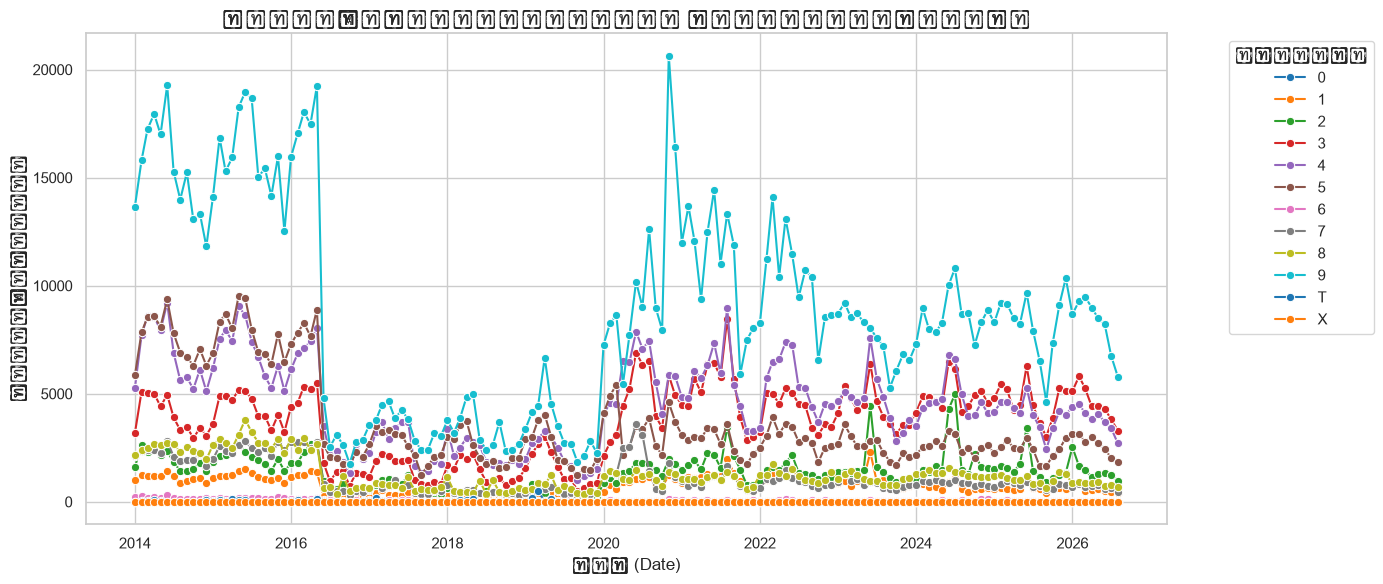

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14, 6))

# สร้าง Line Chart (เปลี่ยน y เป็น 'placed_count' หรือตัวแปรอื่นตามต้องการ)
sns.lineplot(
    data=master_df,
    x='date',
    y='applicants_count',
    hue='รหัส',
    marker='o',
    palette='tab10',
)

plt.title('จำนวนผู้สมัครงานตามเวลา จำแนกตามรหัสอาชีพ', fontsize=14)
plt.xlabel('วันที่ (Date)', fontsize=12)
plt.ylabel('จำนวนผู้สมัครงาน', fontsize=12)
plt.legend(title='รหัสอาชีพ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

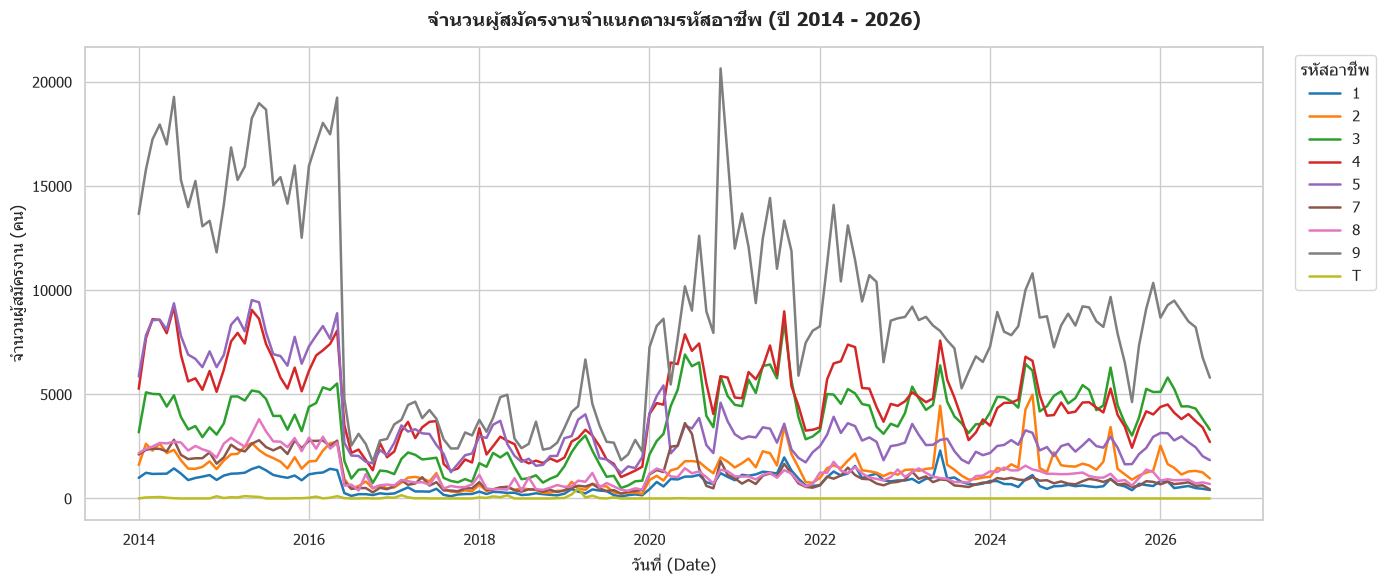

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ตั้งค่าฟอนต์ไทย (เลือกฟอนต์ที่มีในเครื่อง เช่น 'Tahoma', 'TH Sarabun New', 'Garuda')
plt.rcParams['font.family'] = 'Tahoma'

# 2. กรองข้อมูลเฉพาะรหัสที่มีความเคลื่อนไหว (ตัด 0, X ออก)
active_codes = ['1', '2', '3', '4', '5', '7', '8', '9', 'T']
plot_df = master_df[master_df['รหัส'].isin(active_codes)]

# 3. ตั้งค่าธีมและขนาด
sns.set_theme(style='whitegrid', font='Tahoma')
plt.figure(figsize=(14, 6))

# 4. พล็อต Lineplot โดยปิด marker และปรับความหนาเส้น
ax = sns.lineplot(
    data=plot_df,
    x='date',
    y='applicants_count',
    hue='รหัส',
    markers=False,  # เอาจุดออกเพื่อความสะอาดตา
    linewidth=1.8,
    palette='tab10',
)

plt.title(
    'จำนวนผู้สมัครงานจำแนกตามรหัสอาชีพ (ปี 2014 - 2026)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('วันที่ (Date)', fontsize=12)
plt.ylabel('จำนวนผู้สมัครงาน (คน)', fontsize=12)

# จัดวาง Legend ให้อ่านง่าย
plt.legend(
    title='รหัสอาชีพ',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
)
plt.tight_layout()
plt.show()

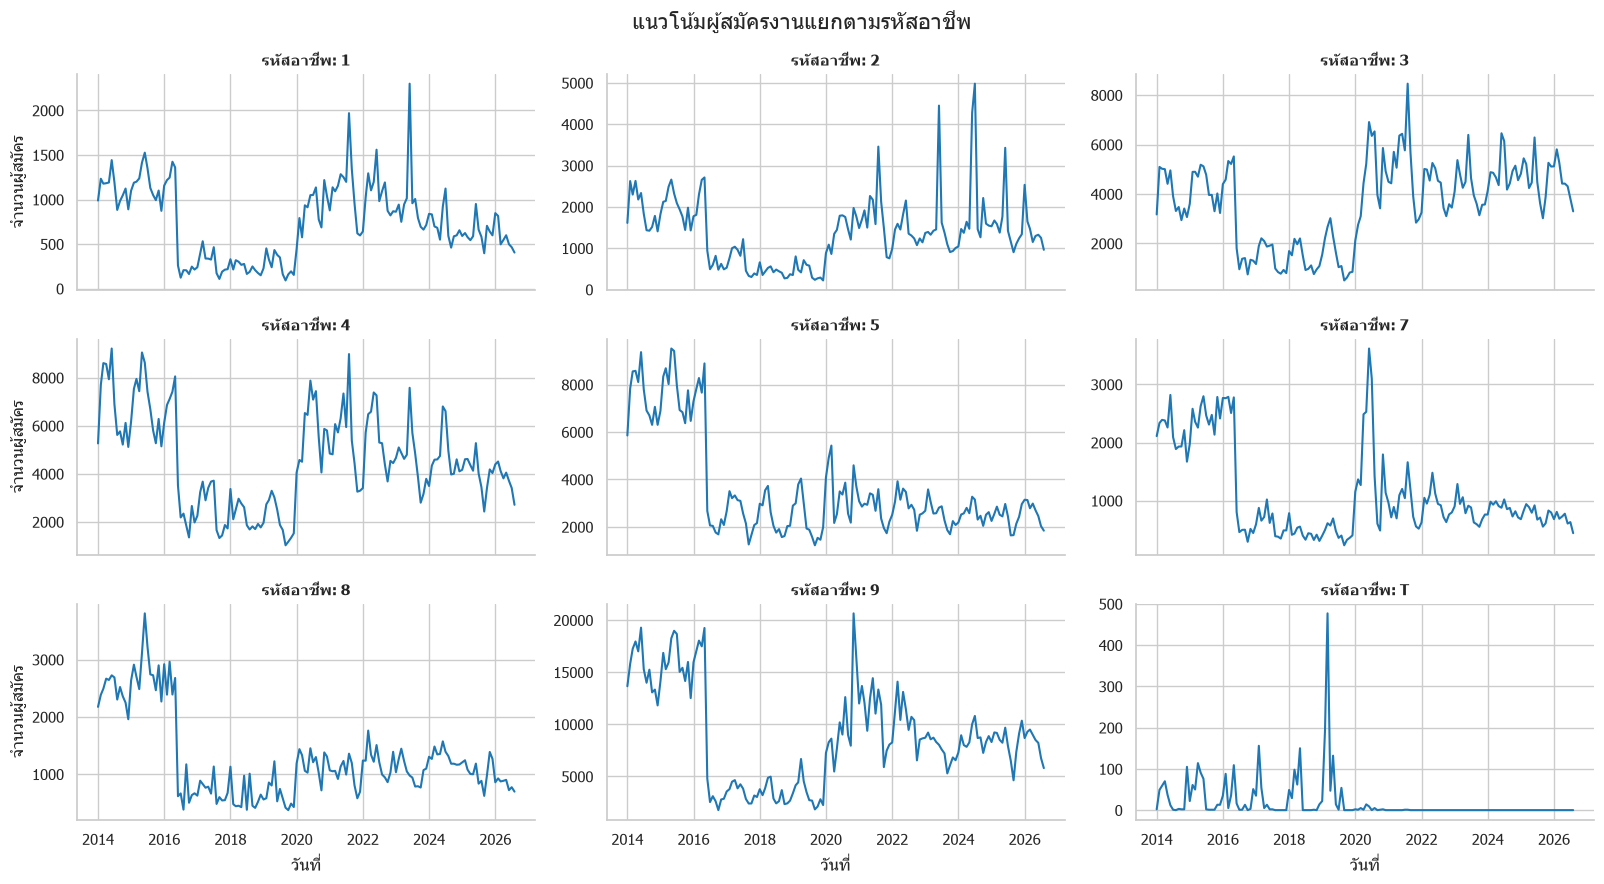

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Tahoma'

# สร้าง FacetGrid แบ่งเป็นช่องๆ ตาม 'รหัส'
g = sns.FacetGrid(
    plot_df,
    col='รหัส',
    col_wrap=3,  # แสดงแถวละ 3 กราฟ
    height=3,
    aspect=1.8,
    sharey=False,  # ปรับสเกล Y แต่ละกราฟอิสระเพื่อให้เห็นรายละเอียดชัดเจน
)

g.map(sns.lineplot, 'date', 'applicants_count', color='#1f77b4', linewidth=1.5)
g.set_titles(col_template='รหัสอาชีพ: {col_name}', size=11, weight='bold')
g.set_axis_labels('วันที่', 'จำนวนผู้สมัคร')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('แนวโน้มผู้สมัครงานแยกตามรหัสอาชีพ', fontsize=16)

plt.tight_layout()
plt.show()

# PCA

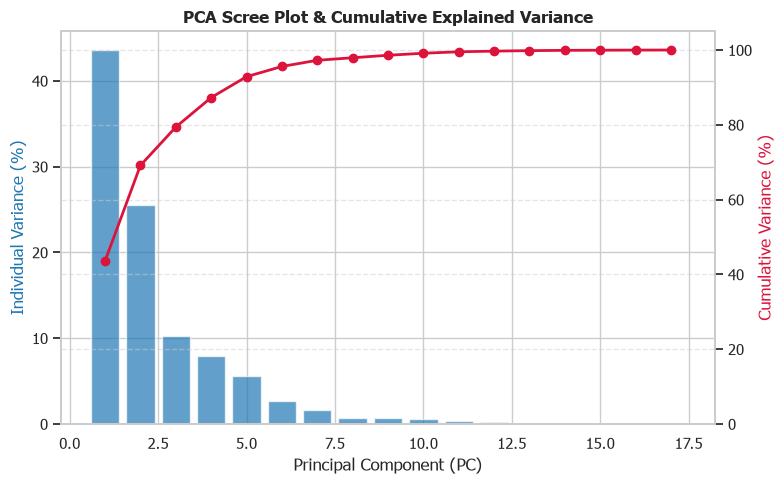

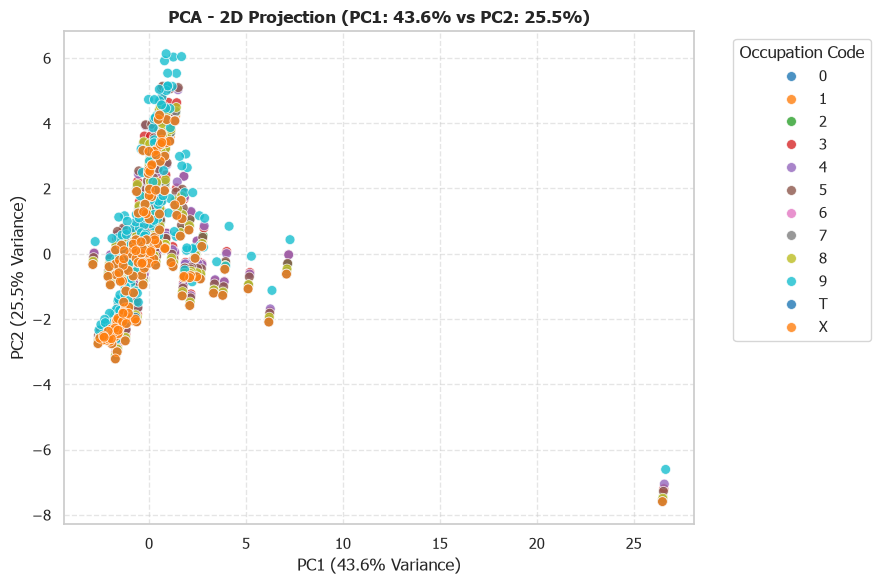

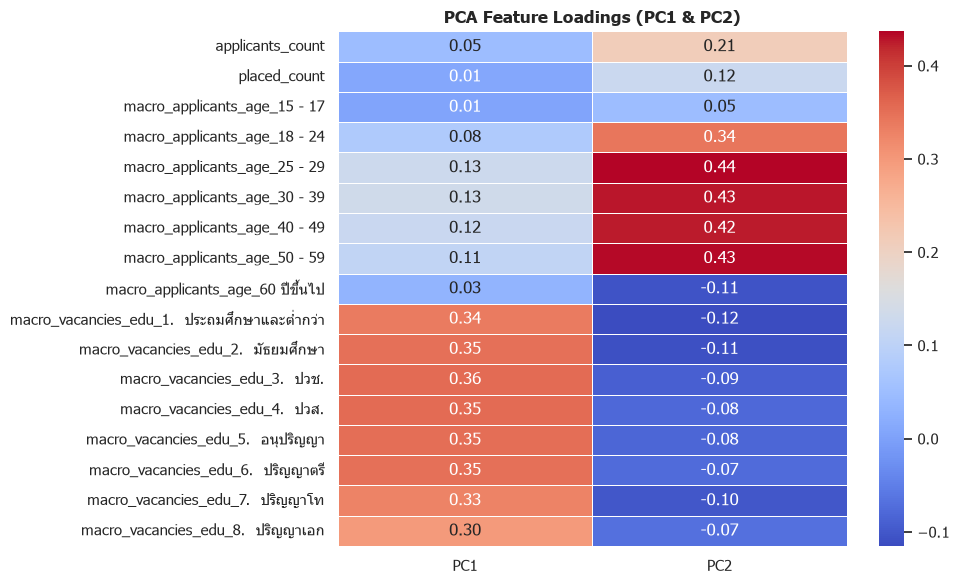

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv('master_dataset_job_prediction.csv')

# 2. คัดเลือกเฉพาะฟีเจอร์ตัวเลขสำหรับ PCA
feature_cols = [c for c in df.columns if c not in ['รหัส', 'date']]
X = df[feature_cols].copy()

# จัดการค่าว่างด้วย Forward/Backward Fill ก่อน Standardize
X = X.ffill().bfill().fillna(0)

# 3. Standardize ข้อมูล (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. ประมวลผล PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

# -------------------------------------------------------------
# 5. Plot 1: Scree Plot & Cumulative Variance
# -------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(range(1, len(exp_var) + 1), exp_var * 100, alpha=0.7, color='#1f77b4', label='Individual Variance (%)')
ax1.set_xlabel('Principal Component (PC)')
ax1.set_ylabel('Individual Variance (%)', color='#1f77b4')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_exp_var) + 1), cum_exp_var * 100, color='crimson', marker='o', linewidth=2, label='Cumulative Variance (%)')
ax2.set_ylabel('Cumulative Variance (%)', color='crimson')
ax2.set_ylim(0, 105)

plt.title('PCA Scree Plot & Cumulative Explained Variance', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 6. Plot 2: 2D Scatter Plot (PC1 vs PC2)
# -------------------------------------------------------------
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df['รหัส'].astype(str), 
    palette='tab10', 
    alpha=0.8, 
    s=50
)
plt.title(f'PCA - 2D Projection (PC1: {exp_var[0]*100:.1f}% vs PC2: {exp_var[1]*100:.1f}%)', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({exp_var[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({exp_var[1]*100:.1f}% Variance)')
plt.legend(title='Occupation Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 7. Plot 3: Feature Loadings Heatmap
# -------------------------------------------------------------
loadings = pd.DataFrame(
    pca.components_[:2, :].T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('PCA Feature Loadings (PC1 & PC2)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()